### 1. Importar librerías

In [1]:
import numpy as np
import xarray as xr
import wavespectra
from wavespectra import read_swan, read_era5, read_ndbc, read_netcdf, read_wwm
import cmocean
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots
import inspect
from sklearn_extra.cluster import CLARA
from pysofar.sofar import SofarApi
from pysofar.spotter import Spotter
import hdpgpc.GPI_HDP as hdpgp
from hdpgpc.get_data import compute_estimators_LDS
from wavespectra.specdataset import SpecDataset
from wavespectra import specarray
import hdpgpc.GPI
import hdpgpc.GPI_model
from matplotlib import gridspec

import xarray as xr
from itertools import combinations
import numpy as np
import xarray as xr

import importlib
import pickle as plk

import torch

from wavespectra.partition import specpart
from wavespectra.core.utils import (
    set_spec_attributes,
    regrid_spec,
    smooth_spec,
    check_same_coordinates,
    D2R,
    celerity,
    is_overlap,
    waveage,
)

C:\Users\marco\anaconda3\envs\hdpgpc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
pio.templates.default = 'plotly'
from plotly.offline import plot

In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from plotly.offline import plot

In [5]:
import warnings
warnings.filterwarnings("ignore", message="Can't decode floating point timedelta to 's'")

In [9]:
import pickle

---

### 2017

In [44]:
# Espectro de energía
ds_wave = xr.open_dataset("../data/NDBC/dir2017_dir.nc", decode_timedelta=True)

# Datos sobre el vientos
ds_meteo = xr.open_dataset("../data/NDBC/meteo2017.nc", decode_timedelta=True)

# Eliminar las dimensiones lat/lon (sólo hay un punto)
ds_meteo = ds_meteo.squeeze(["latitude", "longitude"])

# Convertir variables codificadas a NumPy arrays para evitar problemas de interpolación
for var in ds_meteo.data_vars:
    ds_meteo[var].data = ds_meteo[var].values

# Interpolar viento y profundidad al tiempo del espectro
meteo_interp = ds_meteo.interp(time=ds_wave.time)

# Combinar todo en un nuevo dataset
ds_17 = ds_wave.assign({
    "wspd": meteo_interp["wind_spd"],
    "wdir": meteo_interp["wind_dir"]
})

depth_value = 33.0

dpt_da = xr.DataArray(
    data=np.full_like(ds_17.time, depth_value, dtype=np.float32),
    coords={"time": ds_17.time},
    dims=["time"],
    name="dpt"
)

ds_17["dpt"] = dpt_da

ds_17

<xarray.Dataset> Size: 118MB
Dimensions:    (time: 8694, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2017-01-01 ... 2017-12-31T23:00:00
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B ...
    lon        float32 4B ...
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 118MB ...
    wspd       (time) float64 70kB 7.9 7.1 7.4 5.4 4.2 ... 11.3 11.3 10.8 10.4
    wdir       (time) float64 70kB 274.0 258.0 270.0 262.0 ... 25.0 20.0 16.0
    dpt        (time) float32 35kB 33.0 33.0 33.0 33.0 ... 33.0 33.0 33.0 33.0

### 2018

In [8]:
# Espectro de energía
ds_wave = xr.open_dataset("../data/NDBC/dir2018_dir.nc", decode_timedelta=True)

# Datos sobre el vientos
ds_meteo = xr.open_dataset("../data/NDBC/meteo2018.nc", decode_timedelta=True)

# Eliminar las dimensiones lat/lon (sólo hay un punto)
ds_meteo = ds_meteo.squeeze(["latitude", "longitude"])

# Convertir variables codificadas a NumPy arrays para evitar problemas de interpolación
for var in ds_meteo.data_vars:
    ds_meteo[var].data = ds_meteo[var].values

# Interpolar viento y profundidad al tiempo del espectro
meteo_interp = ds_meteo.interp(time=ds_wave.time)

# Combinar todo en un nuevo dataset
ds_18 = ds_wave.assign({
    "wspd": meteo_interp["wind_spd"],
    "wdir": meteo_interp["wind_dir"]
})

depth_value = 33.0

dpt_da = xr.DataArray(
    data=np.full_like(ds_18.time, depth_value, dtype=np.float32),
    coords={"time": ds_18.time},
    dims=["time"],
    name="dpt"
)

ds_18["dpt"] = dpt_da

ds_18

<xarray.Dataset> Size: 118MB
Dimensions:    (time: 8692, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 70kB 2018-01-01 ... 2018-12-31T23:00:00
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B ...
    lon        float32 4B ...
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 118MB ...
    wspd       (time) float64 70kB 10.5 10.7 12.3 11.2 11.1 ... 1.3 2.2 1.9 2.9
    wdir       (time) float64 70kB 26.0 19.0 13.0 11.0 ... 154.0 167.0 164.0
    dpt        (time) float32 35kB 33.0 33.0 33.0 33.0 ... 33.0 33.0 33.0 33.0

### 3. Filtrado de olas según la relga de Hamilton para aqullas con alturas en el rango (0.5, 2.5)

In [45]:
data_17 = ds_17['efth'].to_numpy()
freq = ds_17['freq'].to_numpy()
dir_17 = ds_17['dir'].to_numpy()

# Datos no direccionales para hacer el filtrado
ds_n_17 = read_ndbc('../data/NDBC/dir2017.nc', directional=False).isel(lat=0, lon=0)
data_no_direct_17 = ds_n_17['efth'].to_numpy()

num_samples, num_obs_per_sample, num_outputs = data_17.shape

In [ ]:
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq[1]-freq[0], num_obs_per_sample)[:, np.newaxis]
hs = 4 * np.sqrt(data_no_direct_17 @ interv)
chosen_indexes = np.where((hs > 0.5) & (hs < 2.5))[0]

In [17]:
#Select indexes
data_17 = data_17[chosen_indexes]
print("Shape of the data: ")
print(data_17.shape)

Shape of the data: 
(7776, 47, 36)


---

In [28]:
data_18 = ds_18['efth'].to_numpy()
freq = ds_18['freq'].to_numpy()
dir_18 = ds_18['dir'].to_numpy()

# Datos no direccionales para hacer el filtrado
ds_n_18 = read_ndbc('../data/NDBC/dir2018.nc', directional=False).isel(lat=0, lon=0)
data_no_direct_18 = ds_n_18['efth'].to_numpy()

num_samples, num_obs_per_sample, num_outputs = data_17.shape

In [ ]:
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq[1]-freq[0], num_obs_per_sample)[:, np.newaxis]
hs = 4 * np.sqrt(data_no_direct_18 @ interv)

chosen_indexes = np.where((hs > 0.5) & (hs < 2.5))[0]


In [29]:
#Select indexes
data_18 = data_18[chosen_indexes]
print("Shape of the data: ")
print(data_18.shape)

num_samples, num_obs_per_sample, num_outputs = data_18.shape

Shape of the data: 
(7568, 47, 36)


### 4. Ajuste de hiperparámetros y ejecución

In [13]:
step = 3
n_blocks = data.shape[0] // step
data_trimmed = data[:n_blocks * step]
data_grouped = data_trimmed.reshape(n_blocks, step, data.shape[1], data.shape[2])
data_avg = data_grouped.mean(axis=1)

In [14]:
data_avg[:, :n_freq, :].shape

(2592, 35, 36)

### 5. Gráficas y resultados

In [10]:
with open("C:/Users/marco/Desktop/def_swgp.pickle", "rb") as f:
    sw_gp = pickle.load(f)

RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 362880 bytes.

In [16]:
import func_plot
from func_plot import plot_cluster_spectrum_and_timeline

In [ ]:
n = ds_subset.dims['time']
labels = np.full(n, fill_value=-1)

for cluster_id, gp in enumerate(sw_gp.gpmodels[0]):
    labels[gp.indexes] = cluster_id
    
ds_subset['cluster_label'] = (('time',), labels)

In [ ]:
ds_subset.to_netcdf('./ds_cluster_14.nc')

In [43]:
ds_means

<xarray.Dataset> Size: 34MB
Dimensions:    (time: 2522, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 20kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 34MB 0.0 0.0 ... 4.316e-05 4.492e-05
    wspd       (time) float64 20kB 7.467 4.867 5.133 5.667 ... 12.53 12.77 13.03
    wdir       (time) float64 20kB 267.3 247.0 224.3 178.0 ... 25.0 36.67 19.33
    dpt        (time) float32 10kB 33.0 33.0 33.0 33.0 ... 33.0 33.0 33.0 33.0

---

In [47]:
# Carga de clustering ya ejecutado
ds_subset = xr.open_dataset("./ds_cluster_14.nc", decode_timedelta=True)
labels = np.unique(ds_subset.cluster_label.values)

ds_17 = ds_17.isel(time=chosen_indexes)

ds_means = ds_17.coarsen(time=3, boundary='trim').mean()

ds_subset["wspd"] = ds_means["wspd"].sel(time=ds_subset.time)
ds_subset["wdir"] = ds_means["wdir"].sel(time=ds_subset.time)

In [48]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:        (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time           (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12...
  * freq           (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat            float32 4B ...
    lon            float32 4B ...
  * dir            (dir) float64 288B 0.0 10.0 20.0 30.0 ... 330.0 340.0 350.0
    latitude       float32 4B ...
    longitude      float32 4B ...
Data variables:
    efth           (time, freq, dir) float64 35MB ...
    cluster_label  (time) int32 10kB 1 1 1 1 1 1 1 1 0 0 ... 2 2 2 1 1 1 1 3 6 6
    wspd           (time) float64 21kB 7.467 4.867 5.133 ... 10.77 11.73 10.83
    wdir           (time) float64 21kB 267.3 247.0 224.3 ... 23.33 19.0 20.33

In [62]:
cluster_means = []
cluster_labels = []
wspd_means = []
wdir_means = []

for c in np.unique(labels):
    ds_cluster = ds_subset.sel(time=ds_subset.cluster_label == c)

    if ds_cluster.time.size == 0:
        continue

    # Media do espectro
    mean_efth = ds_cluster.efth.mean(dim='time') 
    mean_efth = mean_efth.expand_dims(time=[0])
    cluster_means.append(mean_efth)
    cluster_labels.append(int(c))

    # Medias de vento
    wspd_means.append(ds_cluster.wspd.mean(dim='time').expand_dims(time=[0]))
    wdir_means.append(ds_cluster.wdir.mean(dim='time').expand_dims(time=[0]))

# Concatena todas as medias
efth_cluster_means = xr.concat(cluster_means, dim='time')
wspd_cluster_means = xr.concat(wspd_means, dim='time')
wdir_cluster_means = xr.concat(wdir_means, dim='time')

# Crea o dataset final
ds_cluster_means = xr.Dataset({
    'efth': efth_cluster_means,
    'wspd': wspd_cluster_means,
    'wdir': wdir_cluster_means,
    'freq': ds_17.freq,
    'dir': ds_17.dir,
})

# Engade coordenadas de cluster e cambia a dimensión 'time' por 'cluster'
ds_cluster_means = ds_cluster_means.assign_coords(
    cluster=('time', cluster_labels)
)
ds_cluster_means = ds_cluster_means.swap_dims({'time': 'cluster'})

# Copia atributos se os necesitas
ds_cluster_means.efth.attrs = ds_17.efth.attrs
ds_cluster_means.freq.attrs = ds_17.freq.attrs
ds_cluster_means.dir.attrs = ds_17.dir.attrs


In [63]:
ds_cluster_means

<xarray.Dataset> Size: 190kB
Dimensions:    (cluster: 14, freq: 47, dir: 36)
Coordinates:
    time       (cluster) int32 56B 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
  * cluster    (cluster) int32 56B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    efth       (cluster, freq, dir) float64 190kB 0.0 0.0 ... 1.692e-05
    wspd       (cluster) float64 112B 6.089 4.154 4.872 ... 11.49 9.958 3.9
    wdir       (cluster) float64 112B 212.1 179.2 181.9 ... 223.0 234.4 32.67

In [51]:
# Creación de df de medias
cluster_means = []
cluster_labels = []

for c in np.unique(labels):
    ds_cluster = ds_subset.sel(time=ds_subset.cluster_label == c)

    if ds_cluster.time.size == 0:
        continue

    mean_efth = ds_cluster.efth.mean(dim='time') 
    mean_efth = mean_efth.expand_dims(time=[0])
    cluster_means.append(mean_efth)
    cluster_labels.append(int(c))

efth_cluster_means = xr.concat(cluster_means, dim='time')

ds_cluster_means = xr.Dataset({
    'efth': efth_cluster_means,
    'freq': ds_17.freq,
    'dir': ds_17.dir,
})

ds_cluster_means = ds_cluster_means.assign_coords(
    cluster=('time', cluster_labels)
)

ds_cluster_means = ds_cluster_means.swap_dims({'time': 'cluster'})

ds_cluster_means.efth.attrs = ds_17.efth.attrs
ds_cluster_means.freq.attrs = ds_17.freq.attrs
ds_cluster_means.dir.attrs = ds_17.dir.attrs

In [52]:
df = pd.DataFrame({
    'time': pd.to_datetime(ds_subset.time.values),
    'cluster': ds_subset.cluster_label.values
})


df['day'] = df['time'].dt.dayofyear
df['month'] = df['time'].dt.month
df['date'] = df['time'].dt.date

In [53]:
efth_ordered = ds_cluster_means['efth'].transpose('cluster', 'dir', 'freq')
n_clusters = len(labels)

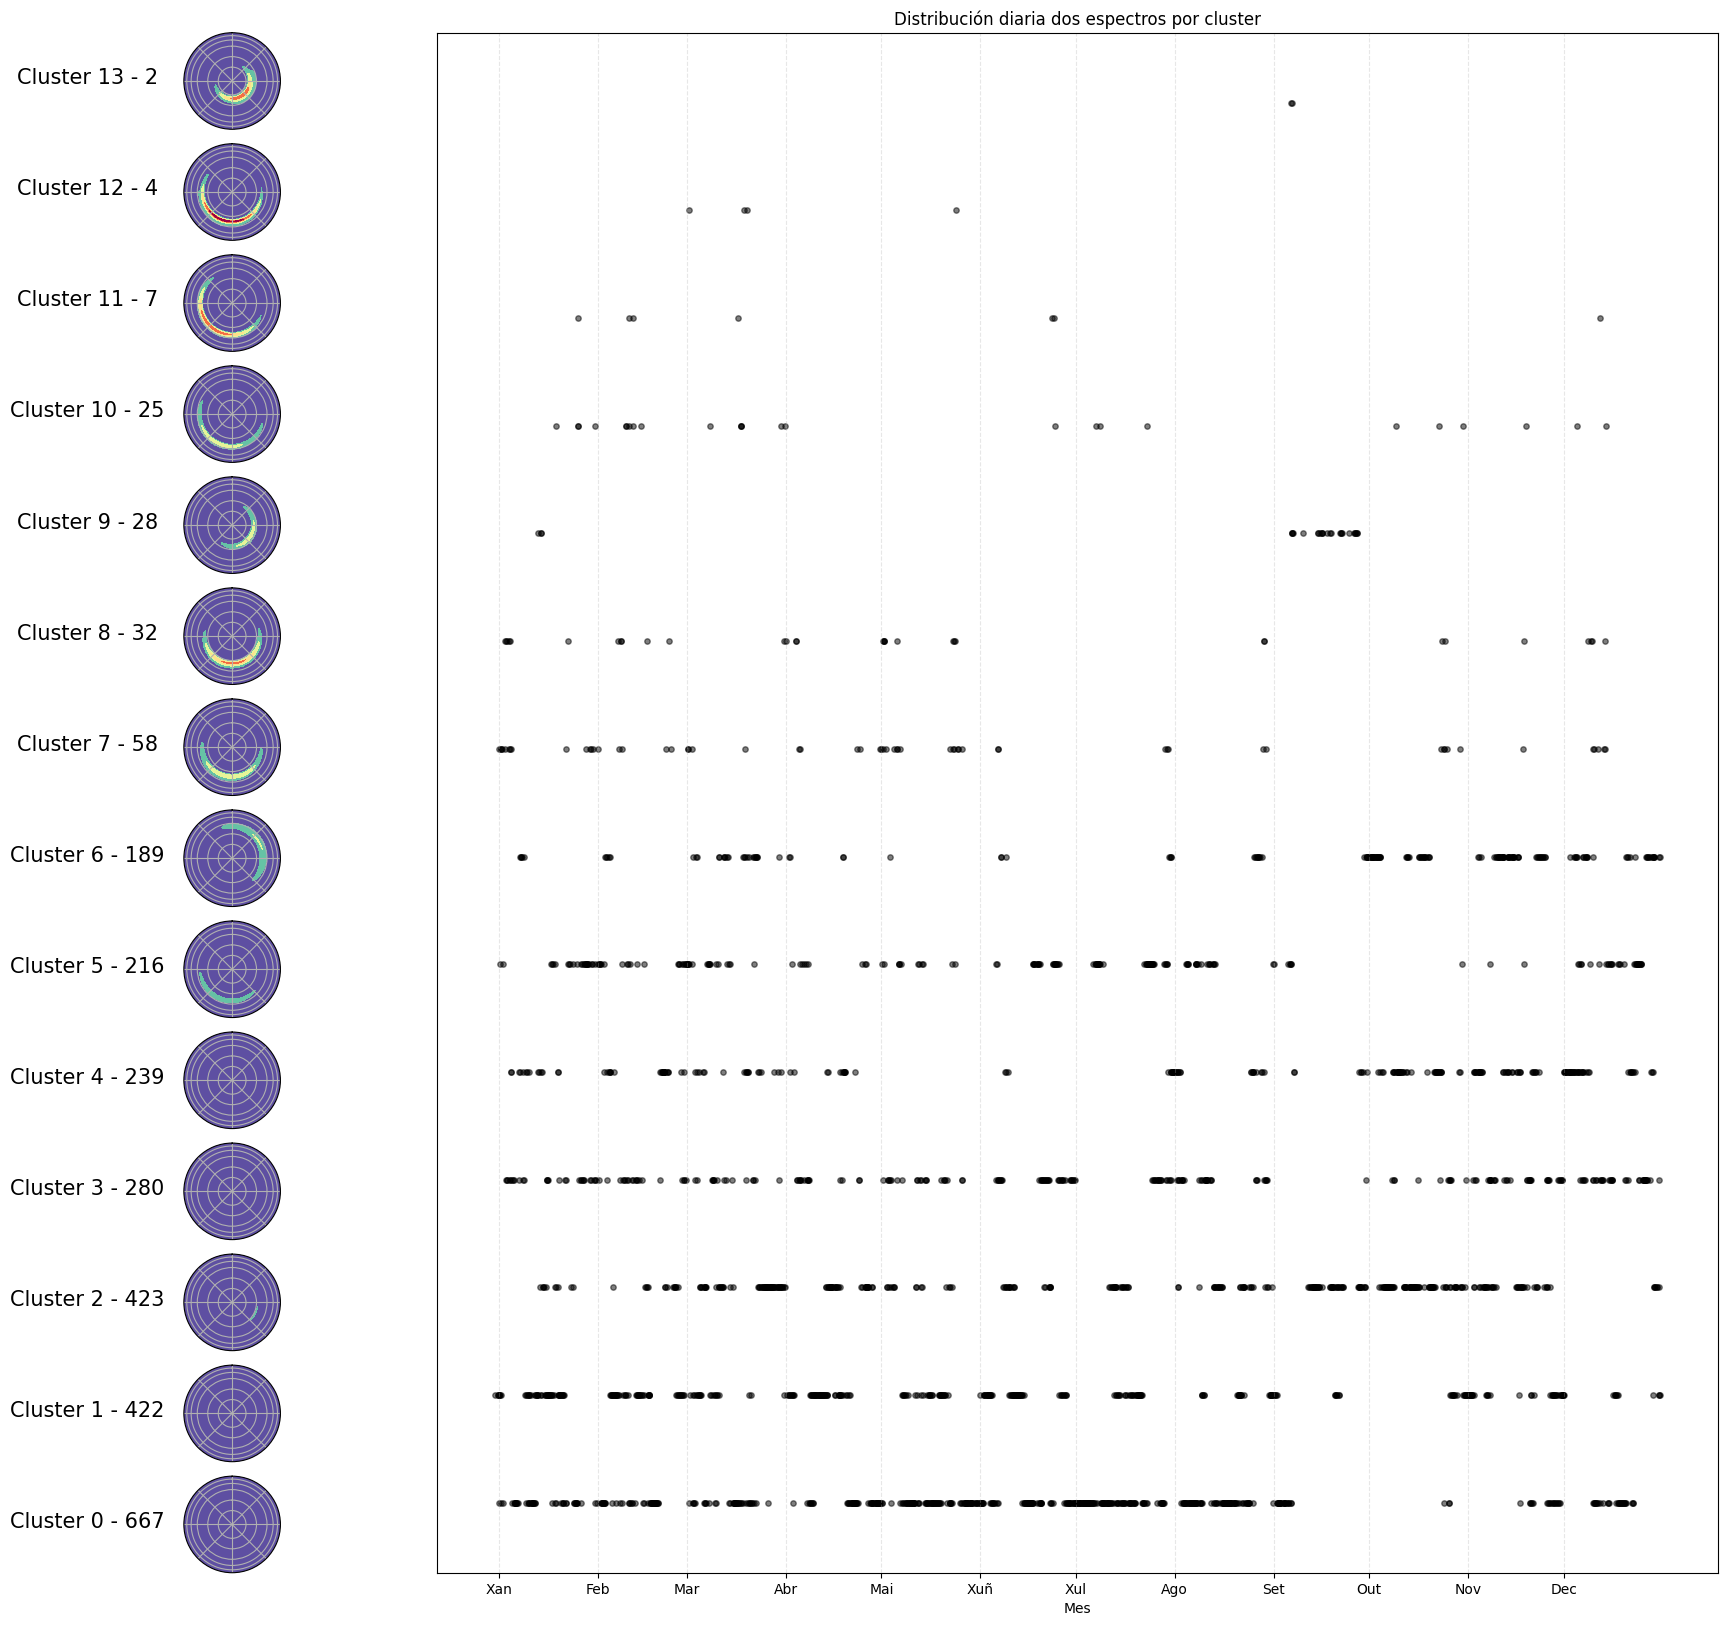

In [18]:
importlib.reload(func_plot)
func_plot.plot_cluster_spectrum_and_timeline(df, efth_ordered, n_clusters, norm=False)

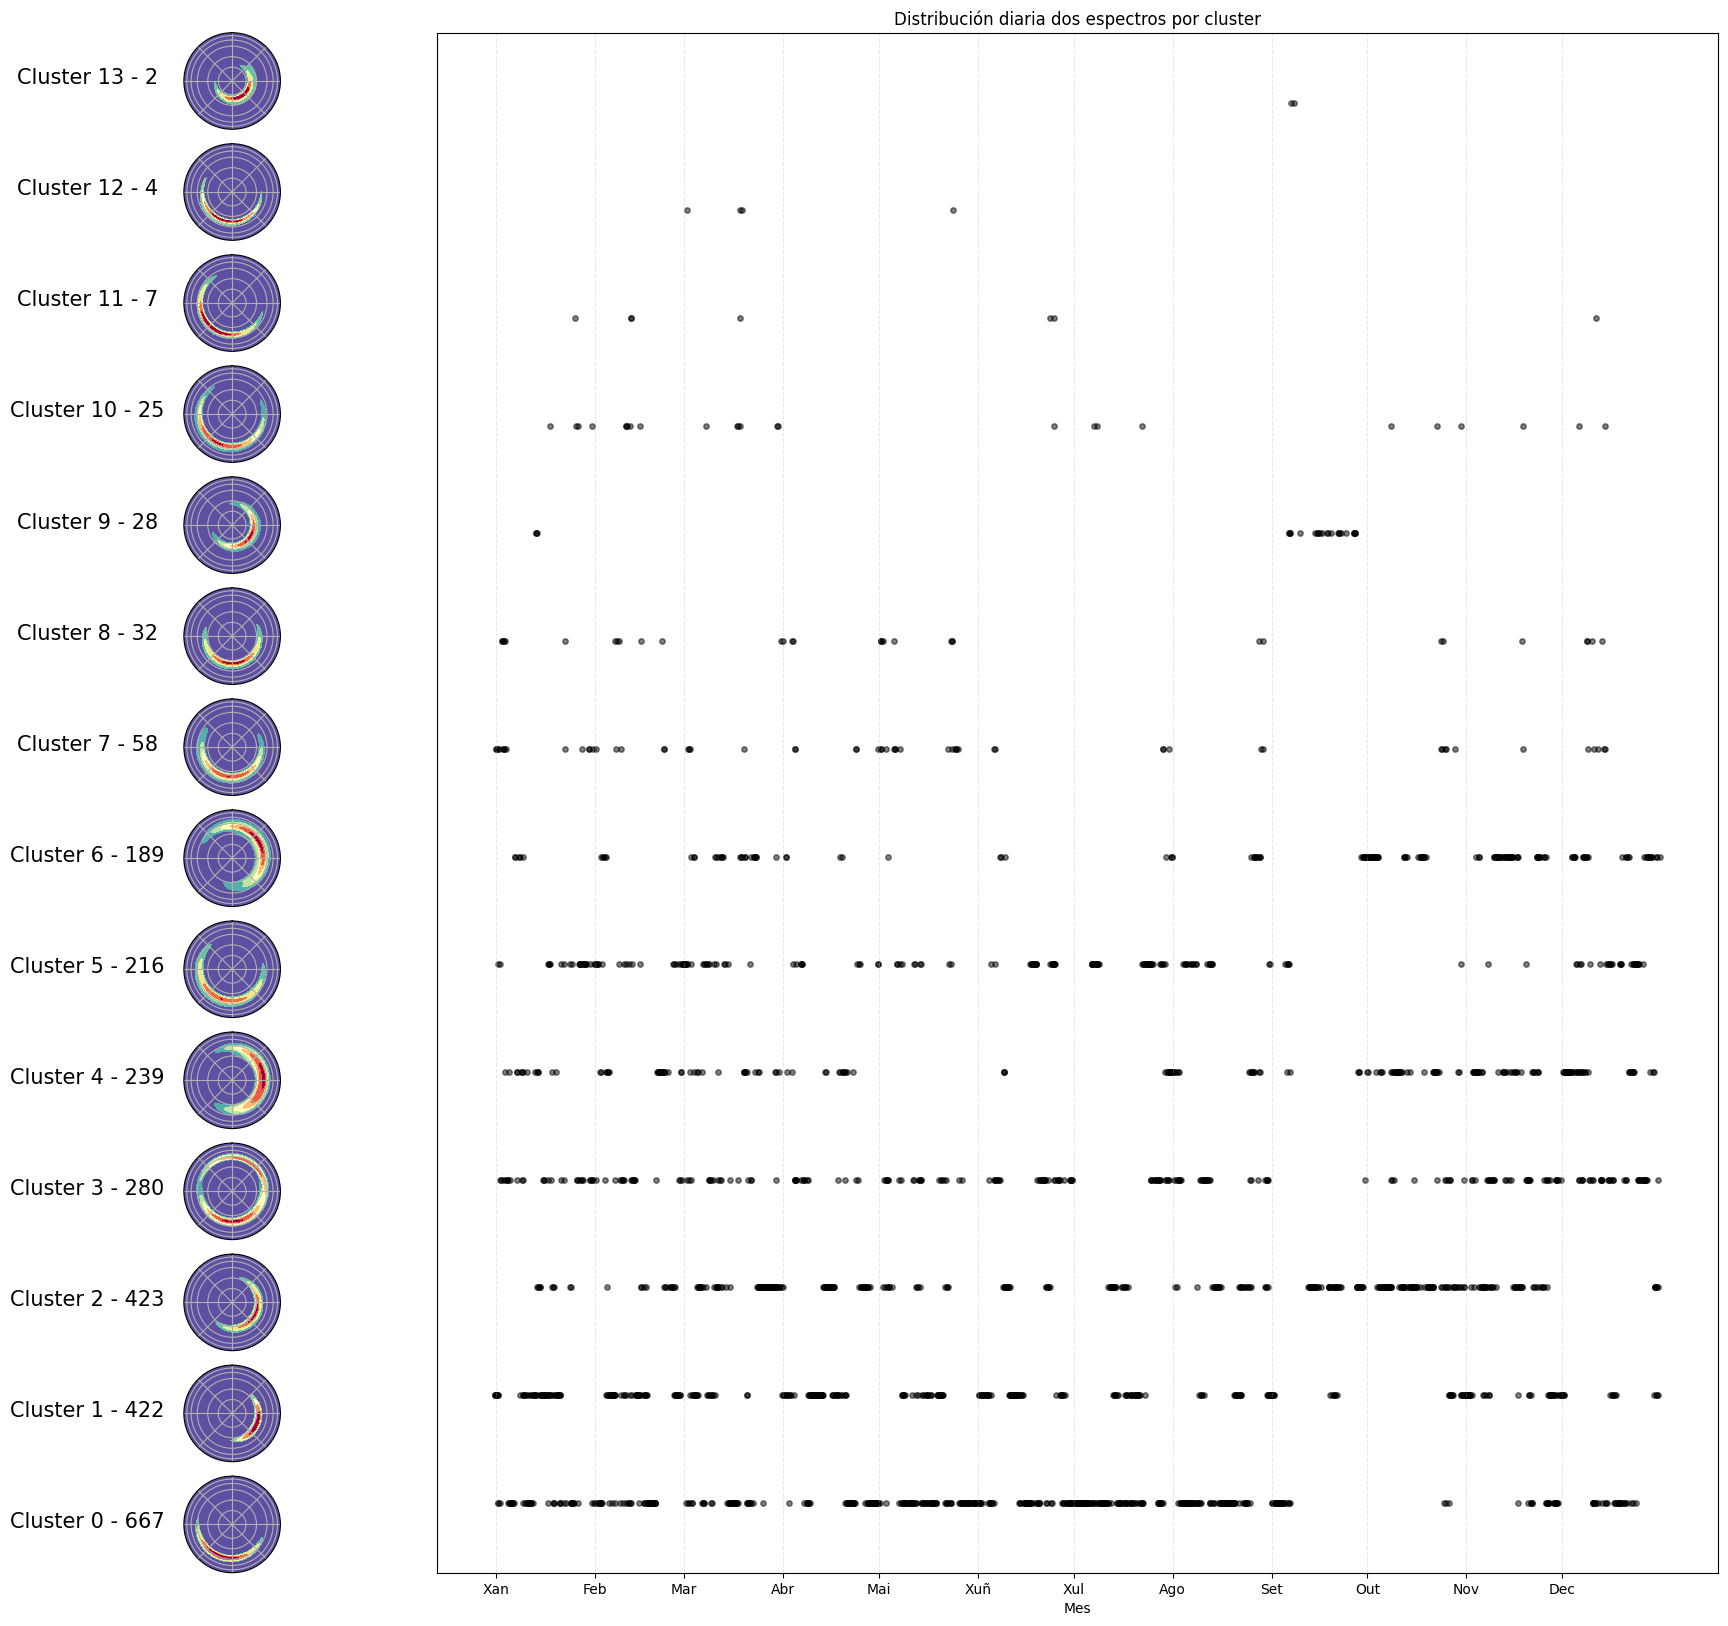

In [17]:
importlib.reload(func_plot)
func_plot.plot_cluster_spectrum_and_timeline(df, efth_ordered, n_clusters, norm=False)

In [54]:
ds_filtered = ds_17.isel(time=chosen_indexes)
ds_subset = ds_filtered[['efth']].coarsen(time=3, boundary='trim').mean()

IndexError: index 7776 is out of bounds for axis 0 with size 7776

In [67]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up

In [16]:
ds_n = read_ndbc('../data/NDBC/dir2017.nc', directional=False).isel(lat=0, lon=0)
ds_filtered = ds_n.isel(time=chosen_indexes)

data_no_direct = ds_filtered[['efth']].coarsen(time=3, boundary='trim').mean()
data_no_direct = data_no_direct['efth'].to_numpy()

windowed_data_no_direct = data_no_direct
max = np.max(windowed_data_no_direct)
num_clusters = n_clusters

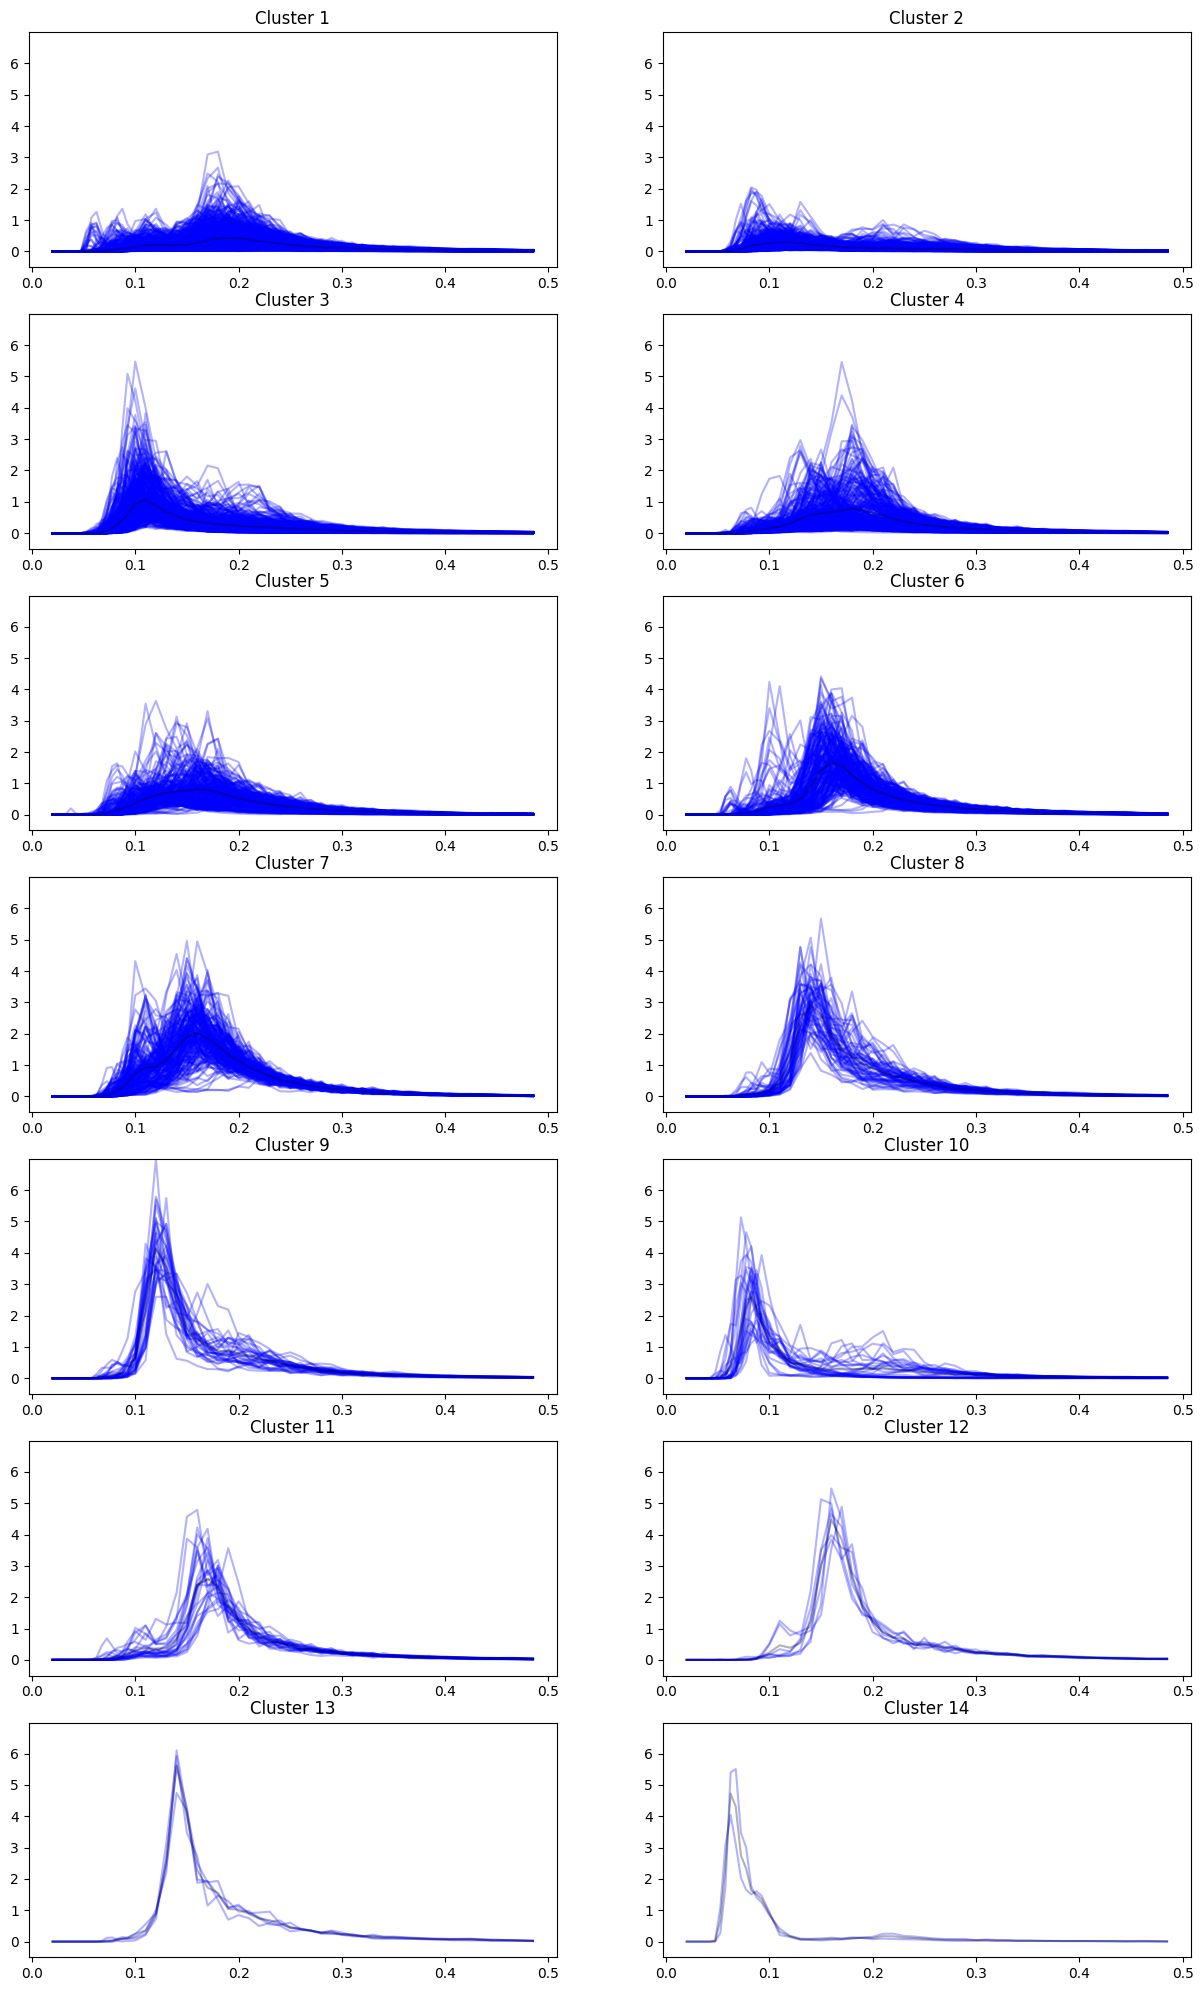

In [23]:
cols = min(2, num_clusters)
rows = (num_clusters // cols) + (num_clusters % cols > 0)
fig, ax = plt.subplots(rows, cols, figsize=(15,25))
for i in range(n_clusters):
    row, col = divmod(i, cols)
    ax[row,col].set_title("Cluster "+str(i+1))
    indices = df[df['cluster'] == i].index
    for j in indices:
        ax[row,col].plot(freq, windowed_data_no_direct[j], 'b', alpha=0.3)
    ax[row,col].plot(freq, np.mean(windowed_data_no_direct[np.array(indices)], axis=0), 'k', alpha=0.3)
    ax[row,col].set_ylim(-0.5, max)

In [55]:
import numpy as np

def classify_partition_portilla(part, freq, dir, wspd, wdir, g=9.81):
    if part.sum() == 0:
        return "null"

    ipeak = np.unravel_index(np.argmax(part, axis=None), part.shape)
    f_peak = freq[ipeak[0]]
    theta_peak = dir[ipeak[1]]
    cp = g / (2 * np.pi * f_peak)
    Ueff = wspd * np.cos(np.radians(theta_peak - wdir))
    waveage = Ueff / cp
    
    if Ueff <= 0:
        return "swell"
    
    beta_min = cp / Ueff
    
    print(beta_min)

    if beta_min <= 1.3:
        return "wind sea"
    elif beta_min <= 2.0:
        return "old wind sea"
    else:
        return "swell"

In [56]:
def hs_func(spec, freq, dir):
    df = np.diff(freq).mean()
    dtheta = np.deg2rad(np.diff(dir).mean())
    m0 = np.sum(spec) * df * dtheta
    return 4 * np.sqrt(m0)


In [57]:
def get_partition_centroid(part, freq, dir):
    energy = part.sum()
    if energy == 0:
        return 0.0, 0.0
    fx = np.sum(part * freq[:, None]) / energy
    dx = np.sum(part * dir[None, :]) / energy
    return fx, dx

def find_closest_partition(i, centroids, valid_idxs):
    fi, di = centroids[i]
    min_dist = float("inf")
    closest = None
    for j in valid_idxs:
        if j == i:
            continue
        fj, dj = centroids[j]
        dist = (fi - fj)**2 + (di - dj)**2
        if dist < min_dist:
            min_dist = dist
            closest = j
    return closest

In [58]:
def np_portilla(
    spectrum,
    spectrum_smooth,
    freq,
    dir,
    wspd,
    wdir,
    dpt,
    swells=None,
    max_parts=10,
    ihmax=500,
    threshold_energy=0.02,
    combine_energy=0.05,
    max_filter_iter=1,
    freq_window=3,
    dir_window=3
):
    total_energy = spectrum.sum()
    filtered = spectrum_smooth.copy()

    for _ in range(max_filter_iter):
        watershed_map = specpart.partition(filtered.values.astype(np.float32), ihmax)
        nparts = watershed_map.max()

        parts = []
        centroids = []
        energies = []

        # Paso 1: gardar todas as particións (sen filtrar)
        for ipart in range(nparts):
            part = np.where(watershed_map == ipart + 1, spectrum, 0.0)
            energy = part.sum()
            parts.append(part)
            centroids.append(get_partition_centroid(part, freq, dir))
            energies.append(energy)

        # Paso 2: combinar particións de baixa enerxía (< threshold_energy)
        valid_idxs = list(range(len(parts)))
        for i in valid_idxs[:]:
            if energies[i] / total_energy < threshold_energy:
                j = find_closest_partition(i, centroids, valid_idxs)
                if j is not None:
                    parts[j] += parts[i]
                    energies[j] += energies[i]
                    valid_idxs.remove(i)

        if len(valid_idxs) <= max_parts:
            break
        else:
            filtered = smooth_spec(filtered, freq_window, dir_window)

    # Paso 5: combinar particións de baixa enerxía (< combine_energy)
    for i in valid_idxs[:]:
        if energies[i] / total_energy < combine_energy:
            j = find_closest_partition(i, centroids, valid_idxs)
            if j is not None:
                parts[j] += parts[i]
                energies[j] += energies[i]
                valid_idxs.remove(i)

    final_parts = [parts[i] for i in valid_idxs]
    labels = []
    classified_parts = []

    for part in final_parts:
        label = classify_partition_portilla(part, freq, dir, wspd, wdir)
        if label != "null":
            classified_parts.append(part)
            labels.append(label)

    swell_parts = [p for p, l in zip(classified_parts, labels) if l != "wind sea"]
    swell_labels = [l for l in labels if l != "wind sea"]
    hs_vals = [-hs_func(p, freq, dir) for p in swell_parts]
    isort = np.argsort(hs_vals)
    swell_parts = list(np.array(swell_parts)[isort])
    swell_labels = list(np.array(swell_labels)[isort])

    print(labels)
    windsea = [p for p, l in zip(classified_parts, labels) if l == "wind sea"]
    windsea_part = np.sum(windsea, axis=0) if windsea else np.zeros_like(spectrum)
    #windsea_part = windsea[0] if windsea else np.zeros_like(spectrum)

    if swells is not None:
        if len(swell_parts) > swells:
            swell_parts = swell_parts[:swells]
            swell_labels = swell_labels[:swells]
        elif len(swell_parts) < swells:
            for _ in range(swells - len(swell_parts)):
                swell_parts.append(np.zeros_like(spectrum))
                swell_labels.append("null")

    all_parts = [windsea_part] + swell_parts
    all_labels = ["wind sea"] + swell_labels
    return np.array(all_parts), all_labels


In [59]:

def ptm_portilla(
    partition, 
    wspd,
    wdir,
    dpt,
    smooth=True,
    freq_window=3,
    dir_window=3,
    ihmax=10000
):
    check_same_coordinates(wspd, wdir, dpt)

    if smooth:
        dset_smooth = smooth_spec(partition.dset, freq_window, dir_window)
    else:
        dset_smooth = partition.dset

    partitions, labels = np_portilla(
        spectrum=partition.dset.values,
        spectrum_smooth=dset_smooth,
        freq=partition.dset.freq.values,
        dir=partition.dset.dir.values,
        wspd=float(wspd),
        wdir=float(wdir),
        dpt=float(dpt),
        swells=None,
        ihmax=ihmax,
    )

    da = xr.DataArray(
        partitions,
        coords={
            "part": np.arange(len(partitions)),
            "freq": partition.dset.freq,
            "dir": partition.dset.dir,
            "label": ("part", labels),
        },
        dims=("part", "freq", "dir"),
        name="efth"
    )

    return da.to_dataset()

In [60]:
ds_cluster_means

<xarray.Dataset> Size: 190kB
Dimensions:    (cluster: 14, freq: 47, dir: 36)
Coordinates:
    time       (cluster) int32 56B 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
  * cluster    (cluster) int32 56B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    efth       (cluster, freq, dir) float64 190kB 0.0 0.0 ... 1.692e-05

In [68]:
dspart = ptm_portilla(
    partition=ds_cluster_means.isel(cluster=8).spec.partition,
    wspd=float(ds_cluster_means.wspd.isel(cluster=8).values),
    wdir=float(ds_cluster_means.wdir.isel(cluster=8).values),
    dpt=33.0,
    smooth=True
)

3.566032175920136
['swell']


C:\Users\marco\AppData\Local\Temp\ipykernel_32852\1341468324.py:3: DeprecationWarning:

self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.



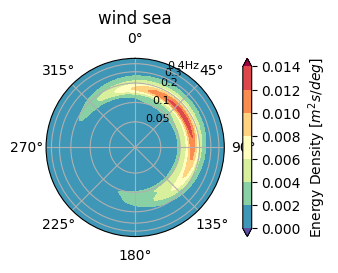

In [65]:
g = dspart.spec.plot(col="part", normalised=False, cmap="Spectral_r", extend='both')

for i, ax in enumerate(g.axes.flat):
    if i < len(dspart.part):
        label = dspart.label.values[i]
        ax.set_title(label)

In [61]:
ds

<xarray.Dataset> Size: 105MB
Dimensions:    (time: 7776, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 62kB 2017-01-01 ... 2017-12-31T23:00:00
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 105MB 0.0 0.0 ... 0.0001682 0.0001788
    wspd       (time) float64 62kB 7.9 7.1 7.4 5.4 4.2 ... 11.3 11.3 10.8 10.4
    wdir       (time) float64 62kB 274.0 258.0 270.0 262.0 ... 25.0 20.0 16.0
    dpt        (time) float32 31kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [63]:

ds_subset = ds.coarsen(time=3, boundary='trim').mean()

In [64]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:    (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 35MB 0.0 0.0 ... 0.0001107 0.0001178
    wspd       (time) float64 21kB 7.467 4.867 5.133 5.7 ... 10.77 11.73 10.83
    wdir       (time) float64 21kB 267.3 247.0 224.3 296.0 ... 23.33 19.0 20.33
    dpt        (time) float32 10kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [101]:
ds2 = ds_subset

col_wrap = 4
n_rows = 2592 // col_wrap
figsize = (15, 3 * n_rows)

ds2.spec.plot(
    normalised=False,
    col="time",
    figsize=figsize,
    cmap="Spectral_r",
    add_colorbar=False,
    col_wrap=col_wrap, 
    col_labels=False
)


Error in callback <function _draw_all_if_interactive at 0x000001E0E675FC40> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



ValueError: Image size of 1500x194400 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 1500x194400 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1500x194400 with 1134 Axes>

In [100]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:    (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 35MB 0.0 0.0 ... 0.0001107 0.0001178
    wspd       (time) float64 21kB 7.467 4.867 5.133 5.7 ... 10.77 11.73 10.83
    wdir       (time) float64 21kB 267.3 247.0 224.3 296.0 ... 23.33 19.0 20.33
    dpt        (time) float32 10kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

---

In [43]:
ds_subset

<xarray.Dataset> Size: 35MB
Dimensions:    (time: 2592, freq: 47, dir: 36)
Coordinates:
  * time       (time) datetime64[ns] 21kB 2017-01-01T01:00:00 ... 2017-12-31T...
  * freq       (freq) float32 188B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    lat        float32 4B 33.44
    lon        float32 4B -77.76
  * dir        (dir) float64 288B 0.0 10.0 20.0 30.0 ... 320.0 330.0 340.0 350.0
    latitude   float32 4B 33.44
    longitude  float32 4B -77.76
Data variables:
    efth       (time, freq, dir) float64 35MB 0.0 0.0 ... 0.0001107 0.0001178

In [32]:
import xarray as xr
import numpy as np

# Creamos Dataset cos espectros e os clusters
ds_freq = xr.Dataset(
    data_vars={
        "efth_freq": (("time", "freq"), windowed_data_no_direct),
        "cluster": ("time", df['cluster'].values),
    },
    coords={
        "time": df['time'].values,
        "freq": freq
    }
)


In [20]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os

In [41]:
output_dir = "cluster_gifs"
os.makedirs(output_dir, exist_ok=True)

unique_clusters = np.unique(ds_freq['cluster'].values)
unique_clusters = [0]

# Array de frecuencias
freq = ds_freq['freq'].values

for cluster_id in unique_clusters:
    # Filtramos o dataset para este cluster
    cluster_ds = ds_freq.sel(time=(ds_freq['cluster'] == 0))
    cluster_ds = cluster_ds.sel(time=slice('2017-07-01', '2017-08-31'))

    # Datos dos espectros dese cluster (numpy array)
    cluster_data = cluster_ds['efth_freq'].values  # shape: (n_times_cluster, n_freqs)
    n_frames = cluster_data.shape[0]

    # Preparar figura
    fig, ax = plt.subplots(figsize=(8, 5))
    line, = ax.plot([], [], color='blue', label="Espectro temporal")
    mean_line, = ax.plot([], [], color='red', linestyle='--', label="Media do cluster")

    ax.set_xlim(freq.min(), freq.max())
    max_val = np.maximum(cluster_data.max(), mean_spectrum.max())  # escolle o maior dos dous
    ax.set_ylim(0, max_val * 1.1)

    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("Enerxía")
    ax.set_title(f"Evolución temporal - Cluster {cluster_id}")
    ax.legend()

    def init():
        line.set_data([], [])
        mean_line.set_data([], [])
        return line, mean_line

    def update(frame):
        y = cluster_data[frame]
        line.set_data(freq, y)
        
        mean_up_to_now = cluster_data[:frame+1].mean(axis=0)
        mean_line.set_data(freq, mean_up_to_now)
        return line, mean_line

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=n_frames,
        init_func=init,
        blit=True,
        interval=150
    )

    gif_path = os.path.join(output_dir, f"cluster_{cluster_id}.gif")
    ani.save(gif_path, writer="pillow")
    plt.close(fig)

print(f"GIFs creados en: {output_dir}")

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


GIFs creados en: cluster_gifs


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import pandas as pd

# Creamos directorio de saída
output_dir = "cluster_cartesian_gif"
os.makedirs(output_dir, exist_ok=True)

# Selección de cluster 0 e datas de xullo a agosto de 2017
ds_filtered = ds_subset.sel(time=ds_subset.time[(ds_subset['cluster_label'] == 0) &
                                                (ds_subset['time'] >= np.datetime64('2017-07-01')) &
                                                (ds_subset['time'] <= np.datetime64('2017-08-31'))])

efth = ds_filtered['efth'].values         # (t, f, d)
freq = ds_filtered['freq'].values         # (f,)
dir_deg = ds_filtered['dir'].values       # (d,)
time_vals = ds_filtered['time'].values    # (t,)

# Convertimos a radianos e coordenadas cartesianas
theta_rad = np.deg2rad(dir_deg)
FREQ, THETA = np.meshgrid(freq, theta_rad, indexing='ij')  # shape: (f, d)
X = FREQ * np.cos(THETA)
Y = FREQ * np.sin(THETA)

# Creamos a figura
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)
cmap = plt.get_cmap('viridis')

# Datos iniciais
current_frame = efth[0, :, :]  # shape: (f, d)
# Inicializa mean_img con algo non todo cero, para ver se se debuxa
#mean_img = ax.pcolormesh(X, Y, current_frame * 0.5, shading='auto', cmap='Reds', alpha=0.5, zorder=2)

# A imaxe principal (o frame actual) → zorder maior para ir enriba
img = ax.pcolormesh(X, Y, current_frame, shading='auto', cmap='viridis', vmin=0, vmax=np.max(efth), zorder=3)


ax.set_aspect('equal')
ax.set_title("Evolución espectral - Cluster 0")
cb = plt.colorbar(img, ax=ax, label="Enerxía")

# Animación
def update(frame):
    current = efth[frame]
    img.set_array(current.ravel())

    # Media acumulada ata este punto
    mean_so_far = efth[:frame+1].mean(axis=0)
    #mean_img.set_array(mean_so_far.ravel())

    timestamp = pd.to_datetime(time_vals[frame]).strftime('%Y-%m-%d %H:%M')
    ax.set_title(f"Cluster 0 – {timestamp}")
    return img

ani = animation.FuncAnimation(
    fig, update, frames=len(efth), blit=False, interval=350
)

# Gardar animación
ani.save(os.path.join(output_dir, "cluster_0_cartesian.gif"), writer="pillow")
plt.close()
print(f"GIF gardado en: {output_dir}")


C:\Users\marco\AppData\Local\Temp\ipykernel_5252\3112681484.py:38: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


GIF gardado en: cluster_cartesian_gif
